# HOUSE PRICE PREDICTION

### Laoding Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("housing.csv")

# Basic info about dataset
print(data.info())  # Columns, data types, missing values check



FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

### Summary stats

In [82]:
print(data.describe())  

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [83]:
print(data.head())  # First few rows

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


### Handling missing values

In [84]:
# Check missing values
print(data.isnull().sum())

# Selecting columns with <3% missing values for imputation
cols = [var for var in data.columns if 0 < data[var].isnull().mean() < 0.03]
print("Columns with <3% missing values:", cols)

# Fill missing values with median
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

# Verify missing values handled
print(data.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Columns with <3% missing values: ['total_bedrooms']
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Data exploration

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

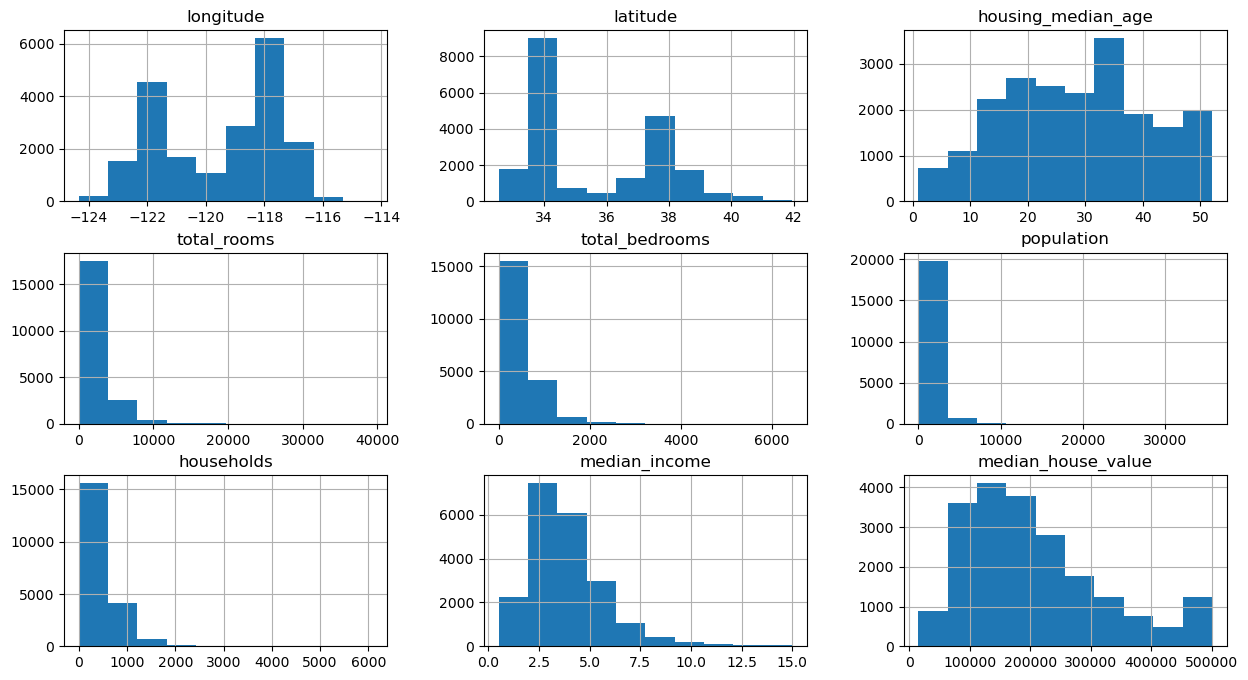

In [85]:
data.hist(figsize=(15, 8))

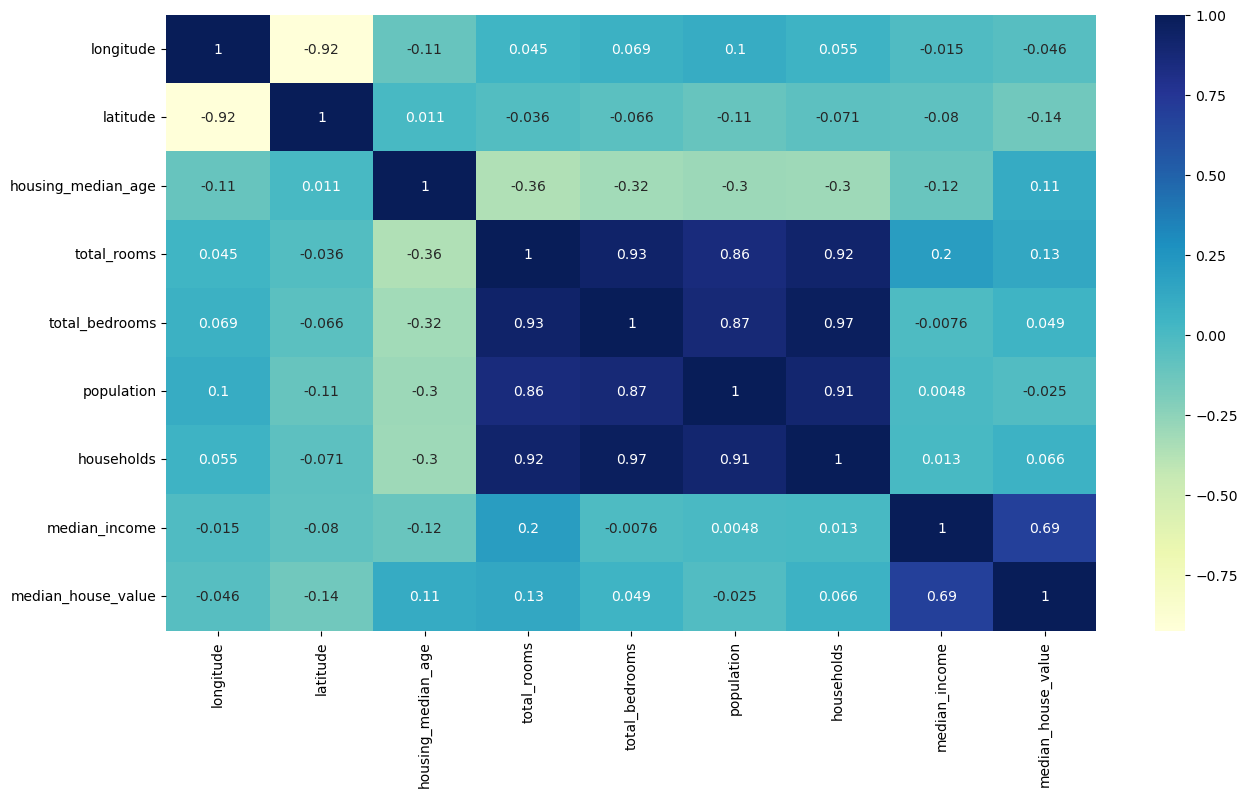

In [86]:
plt.figure(figsize=(15, 8))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap="YlGnBu")
plt.show()


### Count Outliers

In [87]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    total = len(data[column])
    percentage = (outliers / total) * 100
    return outliers, percentage

for col in data.select_dtypes(include=['number']).columns:
    count, percent = count_outliers_iqr(data, col)
    print(f"{col}: {count} outliers ({percent:.2f}%)")


longitude: 0 outliers (0.00%)
latitude: 0 outliers (0.00%)
housing_median_age: 0 outliers (0.00%)
total_rooms: 1287 outliers (6.24%)
total_bedrooms: 1306 outliers (6.33%)
population: 1196 outliers (5.79%)
households: 1220 outliers (5.91%)
median_income: 681 outliers (3.30%)
median_house_value: 1071 outliers (5.19%)


### Log transformation for skewed numerical features

In [108]:
data['total_rooms'] = np.log(data['total_rooms'] + 1)
data['total_bedrooms'] = np.log(data['total_bedrooms'] + 1)
data['population'] = np.log(data['population'] + 1)
data['households'] = np.log(data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'bedroom_ratio'}>,
        <Axes: title={'center': 'household_rooms'}>, <Axes: >]],
      dtype=object)

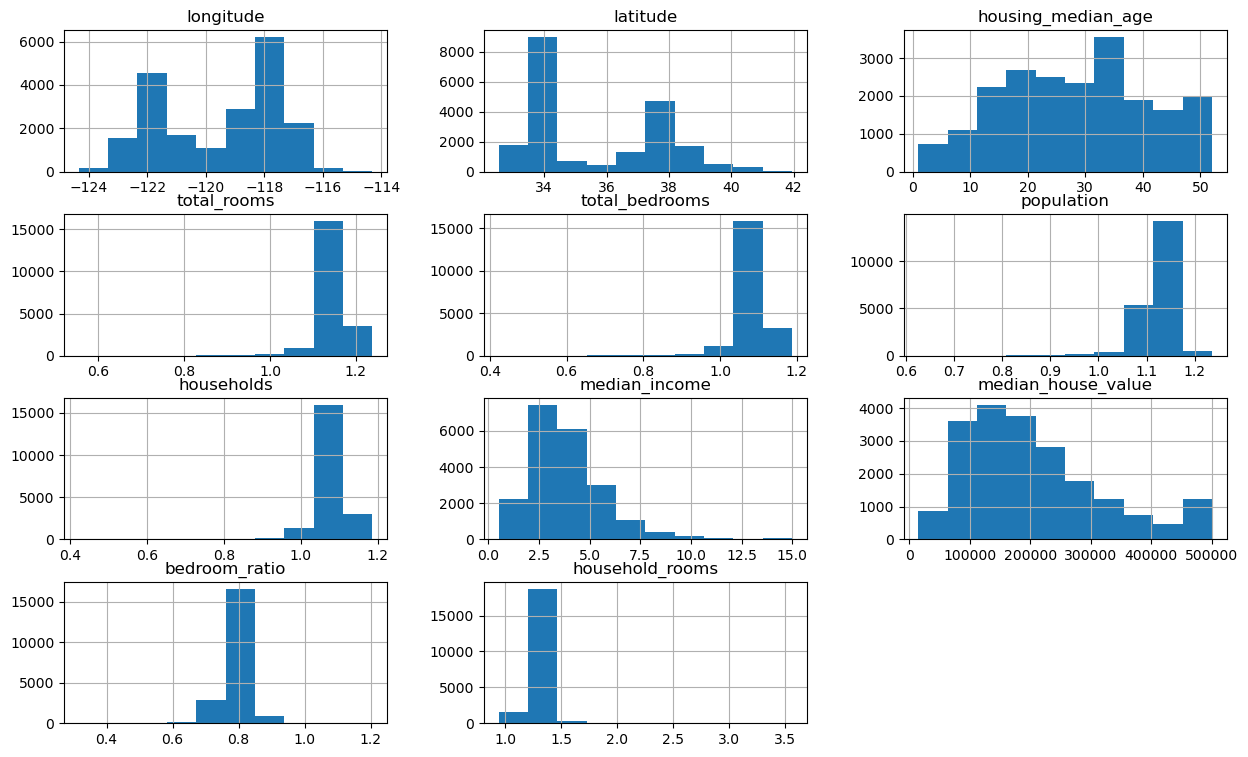

In [109]:
data.hist(figsize=(15, 9))

### Function to Count Outliers After Transformation

In [106]:

def count_outliers(df):
    outlier_info = {}
    
    for col in df.select_dtypes(include=[np.number]):  # Only for numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_percentage = (outliers / len(df)) * 100
        outlier_info[col] = f"{outliers} outliers ({outlier_percentage:.2f}%)"
    
    return outlier_info

#  Get Outliers After Transformation
outlier_counts = count_outliers(data)

# Print the results
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")

longitude: 0 outliers (0.00%)
latitude: 0 outliers (0.00%)
housing_median_age: 0 outliers (0.00%)
total_rooms: 989 outliers (4.79%)
total_bedrooms: 863 outliers (4.18%)
population: 905 outliers (4.38%)
households: 916 outliers (4.44%)
median_income: 681 outliers (3.30%)
median_house_value: 1071 outliers (5.19%)
bedroom_ratio: 537 outliers (2.60%)
household_rooms: 784 outliers (3.80%)


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'bedroom_ratio'}>],
       [<Axes: title={'center': 'household_rooms'}>,
        <Axes: title={'center': 'median_house_value'}>, <Axes: >]],
      dtype=object)

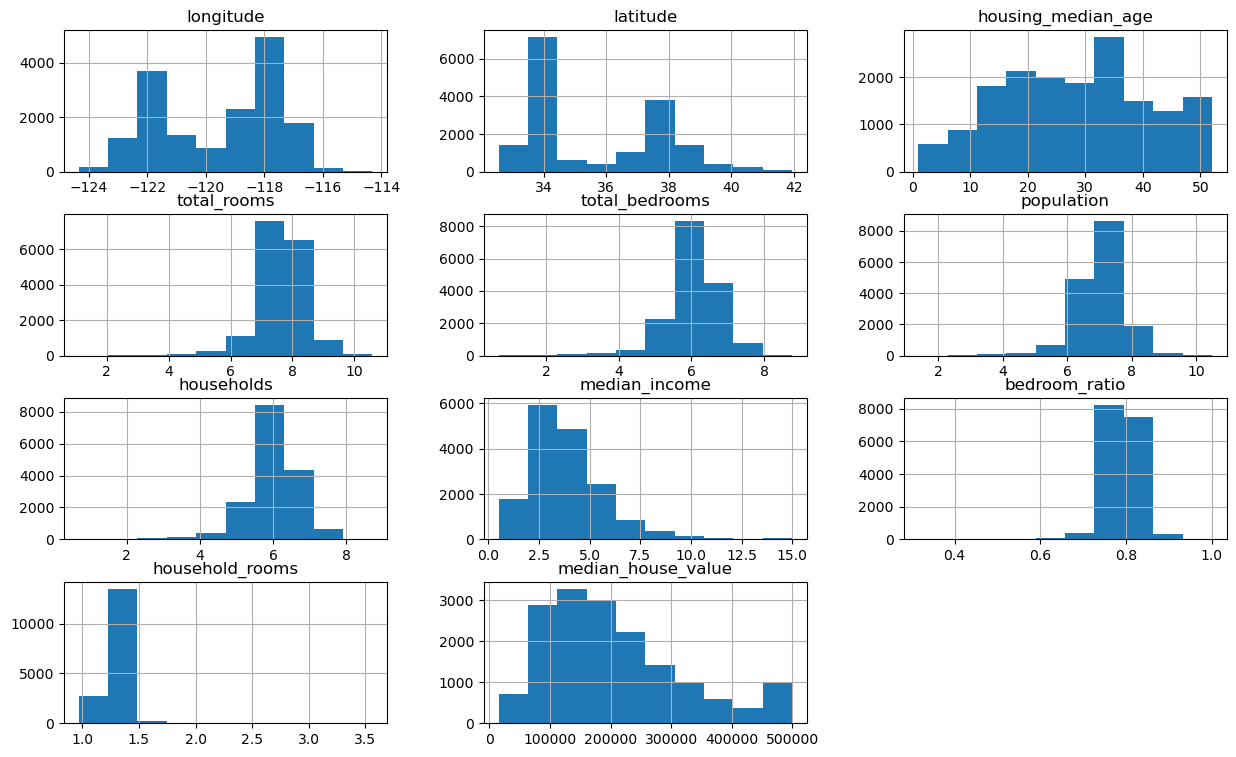

In [107]:
train_data.hist(figsize=(15, 9))

### Encoding Categorical values

In [91]:
# Encoding categorical variable 'ocean_proximity'
print("Categorical columns:", data.select_dtypes(include=['object']).columns)

# Convert categorical column to dummy variables
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

# Creating new feature ratios
data['bedroom_ratio'] = data['total_bedrooms'] / data['total_rooms']
data['household_rooms'] = data['total_rooms'] / data['households']

Categorical columns: Index(['ocean_proximity'], dtype='object')


In [116]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,bedroom_ratio,household_rooms
0,-122.23,37.88,41.0,1.115696,1.018643,1.069400,1.017202,8.3252,452600.0,False,False,True,False,0.717813,1.399834
1,-122.22,37.86,21.0,1.190669,1.125130,1.154658,1.126282,8.3014,358500.0,False,False,True,False,0.790429,1.260013
2,-122.24,37.85,52.0,1.136309,1.041317,1.090336,1.037307,7.2574,352100.0,False,False,True,False,0.720313,1.407171
3,-122.25,37.85,52.0,1.130790,1.052995,1.095758,1.049178,5.6431,341300.0,False,False,True,False,0.764097,1.325768
4,-122.25,37.85,52.0,1.140282,1.062247,1.096325,1.058170,3.8462,342200.0,False,False,True,False,0.762444,1.329892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.141159,1.076849,1.113983,1.070636,1.5603,78100.0,True,False,False,False,0.798973,1.278530
20636,-121.21,39.49,18.0,1.105691,1.027702,1.074418,1.010989,2.5568,77100.0,True,False,False,False,0.766205,1.380045
20637,-121.22,39.43,17.0,1.152381,1.089290,1.121303,1.083935,1.7000,92300.0,True,False,False,False,0.801228,1.271340
20638,-121.32,39.43,18.0,1.145323,1.081200,1.108357,1.073433,1.8672,84700.0,True,False,False,False,0.799078,1.285243


### Spitting training and testing data

In [92]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train & y_train for further preprocessing
train_data = X_train.join(y_train)

# Check shape of train and test data
print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", X_test.shape)


Train Data Shape: (16512, 15)
Test Data Shape: (4128, 14)


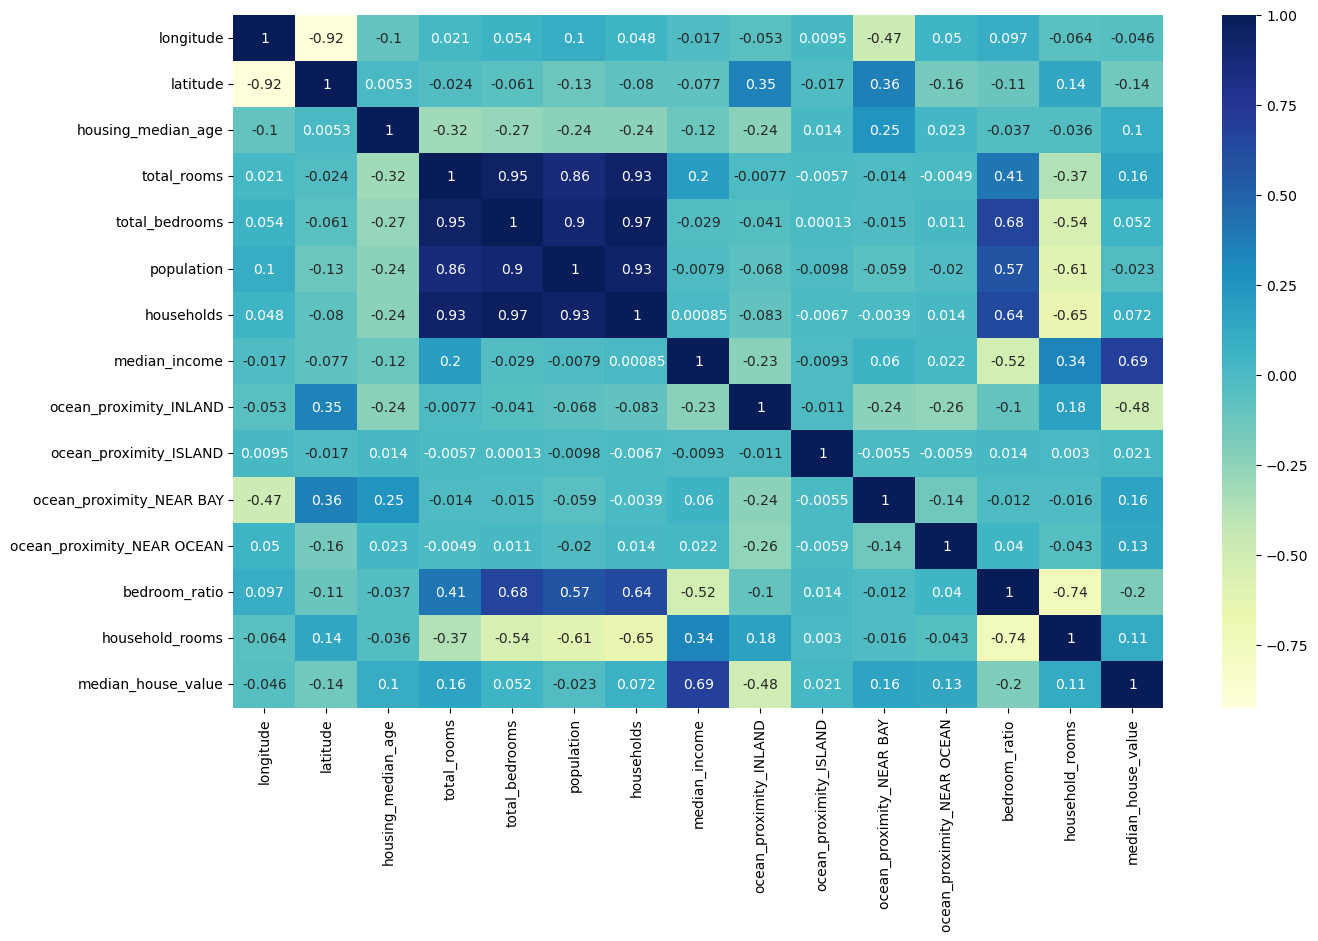

In [125]:
# Correlation heatmap
plt.figure(figsize=(15, 9))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

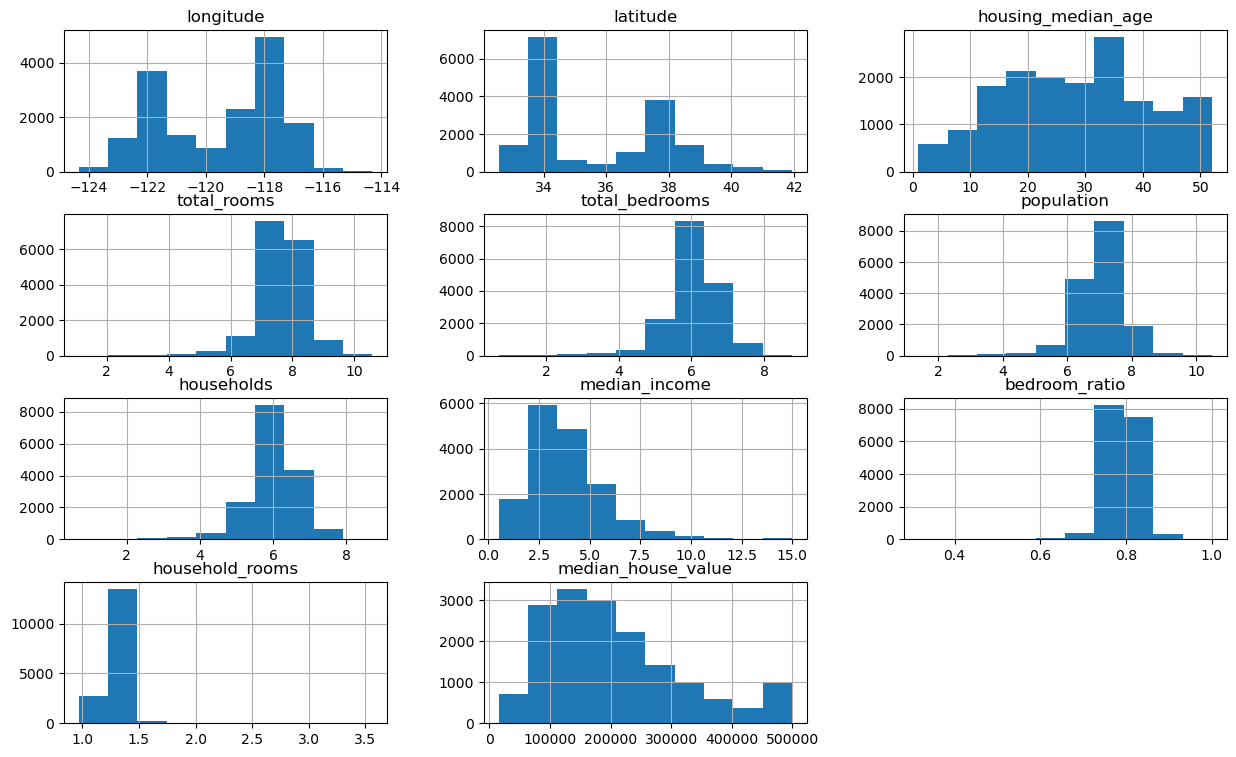

In [127]:
# Histogram of training data features
train_data.hist(figsize=(15, 9))
plt.show()

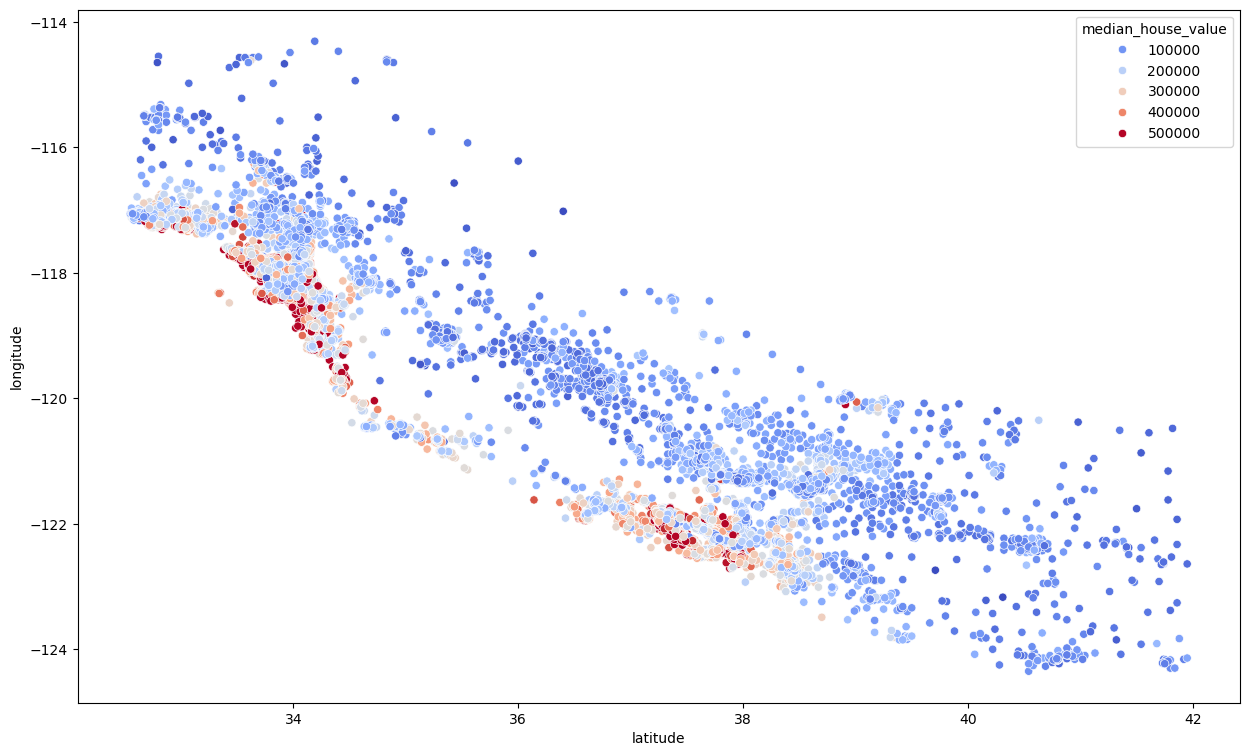

In [126]:
# Scatter plot to analyze location impact on house prices
plt.figure(figsize=(15, 9))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")
plt.show()

### Trying Different Models

In [117]:
from sklearn.linear_model import LinearRegression

# Splitting training data into features (X_train) and target variable (y_train)
X_train = train_data.drop(['median_house_value'], axis=1)
y_train = train_data['median_house_value']

# Initialize and train the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Print model coefficients
print("Model Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)


Model Coefficients: [ -29181.85762661  -28206.32788509    1096.18955635  -79314.63867017
  132150.90054529  -89476.33794582   52373.81635806   42883.65885455
  -33136.4593837   111797.58249453   -8882.98277186   -1816.81870028
 -251519.09954548   14804.19232655]
Intercept: -2162749.08043705


In [118]:
from sklearn.tree import DecisionTreeRegressor

# Initialize Decision Tree model
dt_reg = DecisionTreeRegressor(random_state=42)

# Train model on training data
dt_reg.fit(X_train, y_train)

# Print model details
print("Decision Tree Model Trained Successfully!")


Decision Tree Model Trained Successfully!


In [119]:
# Predict using Linear Regression
y_pred_lr = reg.predict(X_test)

# Predict using Decision Tree Regressor
y_pred_dt = dt_reg.predict(X_test)

# Display first 5 predictions from both models
print("Linear Regression Predictions:", y_pred_lr[:5])
print("Decision Tree Predictions:", y_pred_dt[:5])


Linear Regression Predictions: [ 52264.02597527 112756.69554079 240248.96931364 254079.51738213
 260995.88238313]
Decision Tree Predictions: [ 47500.  26600. 350000. 308000. 319800.]


In [120]:
from sklearn.metrics import mean_squared_error, r2_score

# R² Score (Coefficient of Determination)
r2_lr = r2_score(y_test, y_pred_lr)
r2_dt = r2_score(y_test, y_pred_dt)

# Root Mean Squared Error (RMSE) - Manually taking square root
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print(f"Linear Regression -> R² Score: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}")
print(f"Decision Tree -> R² Score: {r2_dt:.4f}, RMSE: {rmse_dt:.2f}")


Linear Regression -> R² Score: 0.6361, RMSE: 69056.35
Decision Tree -> R² Score: 0.5704, RMSE: 75026.23


In [121]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor ka model initialize karna
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Model ko training data par fit karna
rf_reg.fit(X_train, y_train)

# Test data par predictions karna
y_pred_rf = rf_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

# R² Score
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print(f"Random Forest -> R² Score: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}")


Random Forest -> R² Score: 0.8071, RMSE: 50281.70


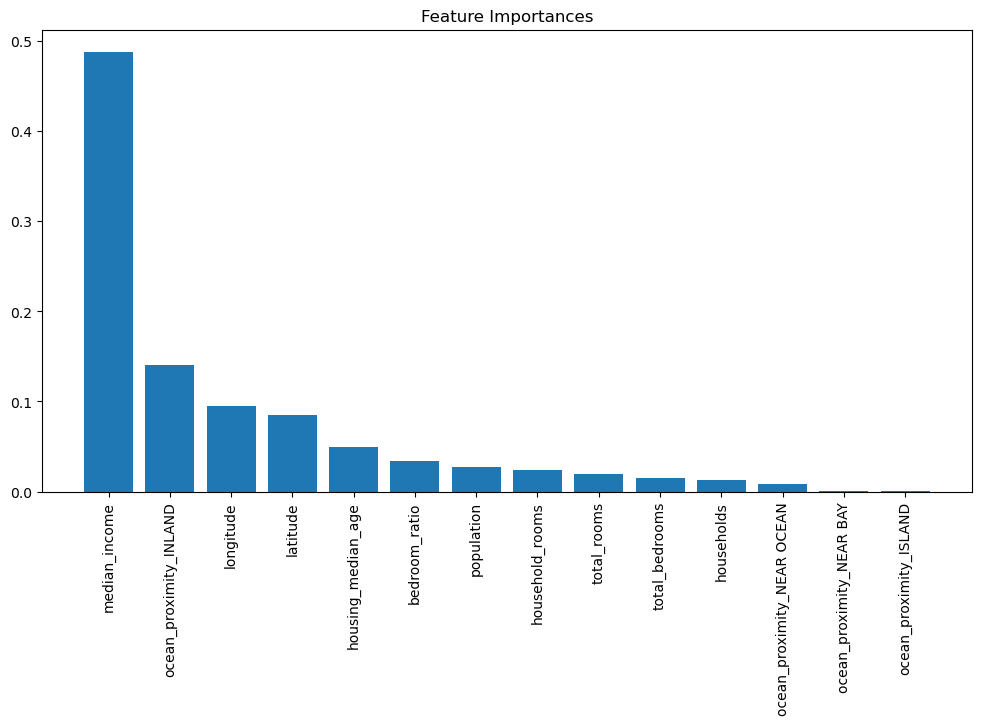

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importances ko nikalna
importances = rf_reg.feature_importances_

# Features ke naam
features = X_train.columns

# Importances ko sort karna
indices = np.argsort(importances)[::-1]

# Plot karna
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices], rotation=90)
plt.show()
